In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

# Global Configurable Fields

In [ ]:
TRAIN_RATIO = 0.05

#Data Preprocessing

In [ ]:
rng = np.random.default_rng(2026)

DATAPATH = "spambase.data"
NAMESPATH = "spambase.names"
dataset = pd.read_csv("spambase.data")

x = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

feature_names = []
with open(NAMESPATH, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("|"):
            continue
        if ":" in line and "continuous" in line:
            feature_names.append(line.split(":")[0].strip())

assert len(feature_names) == 57, f"Expected 57 features, got {len(feature_names)}"

cols = feature_names + ["label"]
dataset = pd.read_csv(DATAPATH, header=None, names=cols)

x = dataset[feature_names]
y = dataset["label"]

print(dataset)
print(dataset.dtypes)
print(dataset.describe())


      word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0               0.00               0.64           0.64           0.0   
1               0.21               0.28           0.50           0.0   
2               0.06               0.00           0.71           0.0   
3               0.00               0.00           0.00           0.0   
4               0.00               0.00           0.00           0.0   
...              ...                ...            ...           ...   
4596            0.31               0.00           0.62           0.0   
4597            0.00               0.00           0.00           0.0   
4598            0.30               0.00           0.30           0.0   
4599            0.96               0.00           0.00           0.0   
4600            0.00               0.00           0.65           0.0   

      word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0              0.32            0.00              0.00     

**Removing Malformed/Missing Data Rows**

In [ ]:
print(x.shape)
x.dropna()
new_x = x.copy()
new_y = y.copy()
offset = 0

for i in range(x.shape[0]):
  drop_row = False
  for j, feature in enumerate(x.columns):
    if not type(x[feature][i]) in [np.int64, np.float64] or x[feature][i] < 0:
      drop_row = True
      break
    elif j in range(54):
      if x[feature][i] > 100:
        drop_row = True
        break
  if not type(y[i]) == np.int64 or not y[i] in [0, 1]:
    drop_row = True
  if drop_row:
    new_x = new_x.drop(index=i - offset, axis="row")
    new_y = new_y.drop(index=i - offset, axis="row")

x = new_x
y = new_y
print(x.shape)

(4601, 57)
(4601, 57)


**Data Visualization**

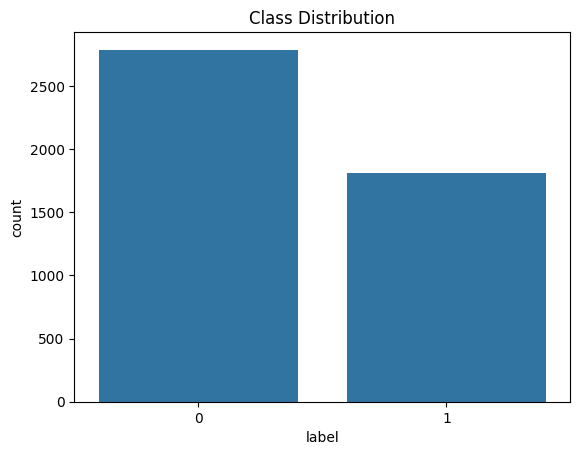

In [ ]:
import seaborn as sns

sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

#Task 1: Logistic Regression with SGD

**Logistic Regression Model**

In [ ]:
class LogisticRegression():
  logistic_fn = lambda x, w: sp.special.expit(np.dot(x, w))
  def __init__(self, regularization_strength):
    self.w = []
    self.regularization_strength = regularization_strength

  def fit(self, x, y, graddesc):
    x = np.column_stack([np.ones(x.shape[0]), x]).astype('float')
    self.w = graddesc.run(self.gradient, x, y)

  def predict(self, x):
    x = np.column_stack([np.ones(x.shape[0]), x]).astype('float')
    return LogisticRegression.logistic_fn(x, self.w)

  def cost(self, y_pred, y_act):
    y_pred = np.array(y_pred)
    y_act = np.array(y_act)
    # Compute mean of costs
    cost = -sp.special.xlogy(y_act, y_pred) - sp.special.xlogy(1 - y_act, 1 - y_pred)
    cost[cost == np.inf] = 1 # if cost is inf, then we had a pred of 1, and actual label of 0, or vice-versa. Apply high cost.
    return np.mean(cost) + self.regularization_strength/2 * (np.linalg.norm(self.w[1:]) ** 2)

  def gradient(self, w, x, y):
    result = np.dot(x.T, (LogisticRegression.logistic_fn(x, w) - y)) / x.shape[0]
    return result + self.regularization_strength * (np.insert(w[1:], 0, 0, axis=0))

  def accuracy(self, y_act, y_pred):
    y_act = np.array(y_act)
    y_pred = np.array(y_pred)
    tp = len([i for i in range(y_act.shape[0]) if round(y_pred[i]) == y_act[i] and y_act[i]])
    tn = len([i for i in range(y_act.shape[0]) if round(y_pred[i]) == y_act[i] and not y_act[i]])
    return (tp + tn) / y_pred.shape[0]

**Gradient Descent Algorithm**<br>NOTE: As a bonus, our algorithm also supports momentum.

In [ ]:
class GradientDescent():
  def __init__(self, learning_rate, max_iters, batch_size, epsilon, momentum=0, track_cost_per_update=False, reg_strength=0,
               w_init=None):
    self.learning_rate = learning_rate
    self.max_iters = max_iters
    self.batch_size = batch_size
    self.epsilon = epsilon
    self.momentum = momentum
    self.track_cost_per_update = track_cost_per_update
    self.reg_strength = reg_strength
    self.cost_per_update = []
    self.accuracy_per_update = []
    self.w_init = w_init

  def run(self, gradient_fn, x, y):
    x = np.array(x)
    y = np.array(y)
    # Random shuffling
    batches = rng.choice(x.shape[0], x.shape[0], replace=False)
    g = np.inf
    w_momentum = np.zeros(x.shape[1])
    w = self.w_init or np.zeros(x.shape[1])
    counter = 0
    indx = 0

    if self.track_cost_per_update:
      self.cost_per_update = []
      logistic_model = LogisticRegression(self.reg_strength)
      logistic_model.w = w
      y_pred = logistic_model.predict(x[:,1:])
      self.cost_per_update.append(logistic_model.cost(y_pred, y))
      self.accuracy_per_update.append(logistic_model.accuracy(y, logistic_model.predict(x[:,1:])))

    while counter < self.max_iters and g > self.epsilon:
      batch_x = np.zeros((self.batch_size, x.shape[1]))
      batch_y = np.zeros((self.batch_size))
      for i in range(self.batch_size):
        batch_x[i] = x[batches[indx]][:]
        batch_y[i] = y[batches[indx]]
        indx += 1
        if indx >= x.shape[0]:
          # End of epoch; reset and perform random shuffling
          batches = rng.choice(x.shape[0], x.shape[0], replace=False)
          indx = 0

      grad = gradient_fn(w, batch_x, batch_y)
      g = np.linalg.norm(grad)
      w_momentum = self.momentum * w_momentum + (1 - self.momentum) * grad
      w = w - self.learning_rate * w_momentum

      if self.track_cost_per_update:
        logistic_model.w = w
        y_pred = logistic_model.predict(x[:,1:])
        self.cost_per_update.append(logistic_model.cost(y_pred, y))
        self.accuracy_per_update.append(logistic_model.accuracy(y, logistic_model.predict(x[:,1:])))
      counter += 1
    return w

**Performance Metrics**

In [ ]:
def eval_binary_metrics(y_true, y_prob, thresh=0.5):
    y_true = np.array(y_true).astype(int).reshape(-1)
    y_prob = np.array(y_prob).reshape(-1)
    y_pred = (y_prob >= thresh).astype(int)

    tp = np.sum((y_pred == 1) & (y_true == 1)) #true positive -> correctly predicted spam
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))

    precision = tp / (tp + fp + 1e-12) #Of all emails predicted as spam, how many were actually spam
    recall    = tp / (tp + fn + 1e-12)
    f1        = 2 * precision * recall / (precision + recall + 1e-12)

    return {"tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "precision": precision, "recall": recall, "f1": f1}

**Split Train/Test Sets**

In [ ]:
# Random Train/Test Dataset Split
def split_train_test(ratio=TRAIN_RATIO, verbose=False):
  train_size = int(ratio * x.shape[0])

  batches = rng.choice(x.shape[0], x.shape[0], replace=False)
  train_bin = set(rng.choice(x.shape[0], train_size, replace=False))
  test_bin = set(range(x.shape[0])).difference(train_bin)

  x_train, y_train = x.iloc[sorted(list(train_bin))], y.iloc[sorted(list(train_bin))]
  x_test, y_test =  x.iloc[sorted(list(test_bin))], y.iloc[sorted(list(test_bin))]

  # Standardize using TRAIN statistics only (prevents data leakage)
  train_mean = x_train.mean()
  train_std = x_train.std().replace(0, 1)

  x_train = (x_train - train_mean) / train_std
  x_test  = (x_test  - train_mean) / train_std

  if verbose:
    print(f"Train mean: {x_train.mean().mean()}")
    print(f"Train std_dev: {x_train.std().mean()}")

  return x_train, x_test, y_train, y_test

x_train, x_test, y_train, y_test = split_train_test()

**Sample Execution**<br>Regularization Stength = 0.001<br> Learning Rate = 0.1<br> Batch Size = 64<br> NOTE: This is just a sample execution. We perform hyperparameter tuning in the following section. To visualize the learning curves when no regularization is applied, set the REGULARIZATION_STRENGTH value to 0. Similarly, for SGD with batch size of 1, set BATCH_SIZE to 1.

In [ ]:
# Hyperparameters
REGULARIZATION_STRENGTH = 0.001
LEARNING_RATE = 0.1
BATCH_SIZE = 64
NUM_EPOCHS = 200
EPSILON = 0.0001

In [ ]:
#. Train & Test Model
graddesc = GradientDescent(LEARNING_RATE, NUM_EPOCHS, BATCH_SIZE, EPSILON, 0, True, REGULARIZATION_STRENGTH)
logistic_model = LogisticRegression(REGULARIZATION_STRENGTH)
logistic_model.fit(x_train, y_train, graddesc)
print("--TRAIN SET--")
y_pred = logistic_model.predict(x_train)

print(f"Cross-Entropy Loss: {logistic_model.cost(y_pred, y_train)}")
print(f"Accuracy: {logistic_model.accuracy(y_train, y_pred)}")
diff = [i for i in range(y_pred.shape[0]) if round(y_pred[i]) != np.array(y_train)[i]]
print(f"Our Model - {len(diff)} ({len(diff)/y_pred.shape[0] * 100}%) misclassified")

print("--TEST SET--")
y_pred = logistic_model.predict(x_test)
print(f"Cross-Entropy Loss: {logistic_model.cost(y_pred, y_test)}")
print(f"Accuracy: {logistic_model.accuracy(y_test, y_pred)}")
diff = [i for i in range(y_pred.shape[0]) if round(y_pred[i]) != np.array(y_test)[i]]
print(f"Our Model - {len(diff)} ({len(diff)/y_pred.shape[0] * 100}%) misclassified")

--TRAIN SET--
Cross-Entropy Loss: 0.1762528383004403
Accuracy: 0.9521739130434783
Our Model - 11 (4.782608695652174%) misclassified
--TEST SET--
Cross-Entropy Loss: 0.32107902175770753
Accuracy: 0.8888126286890872
Our Model - 486 (11.118737131091283%) misclassified


In [ ]:
#proper evaluation metrics (confusion matrix, precision/recall/F1)

metrics = eval_binary_metrics(y_test, y_pred, thresh=0.5)
print(metrics)

{'tp': np.int64(1412), 'fp': np.int64(175), 'fn': np.int64(311), 'tn': np.int64(2473), 'precision': np.float64(0.8897290485192182), 'recall': np.float64(0.8195008705745788), 'f1': np.float64(0.8531722054375669)}


**Cross-Entropy Loss vs Gradient Update Iteration**

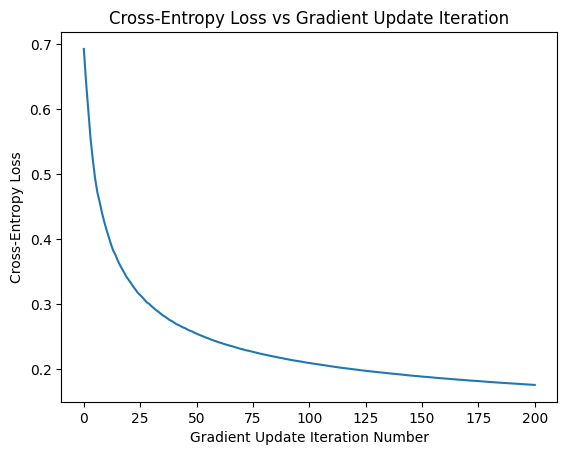

In [ ]:
plt.plot(range(len(graddesc.cost_per_update)), graddesc.cost_per_update)
plt.title("Cross-Entropy Loss vs Gradient Update Iteration")
plt.xlabel("Gradient Update Iteration Number")
plt.ylabel("Cross-Entropy Loss")
plt.show()

**Accuracy vs Gradient Update Iteration**

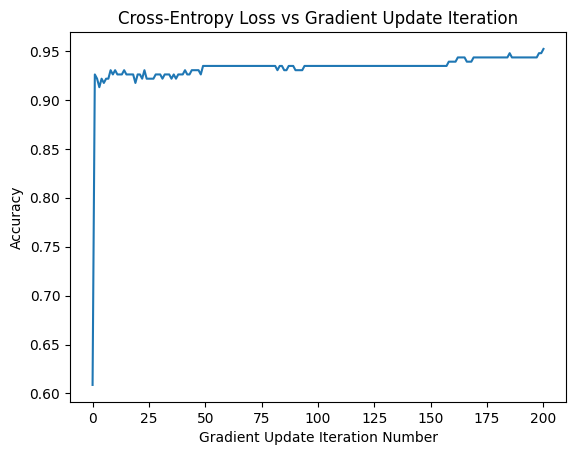

In [ ]:
plt.plot(range(len(graddesc.accuracy_per_update)), graddesc.accuracy_per_update)
plt.title("Cross-Entropy Loss vs Gradient Update Iteration")
plt.xlabel("Gradient Update Iteration Number")
plt.ylabel("Accuracy")
plt.show()

**BONUS: Effect of Momentum**

--TRAIN SET--
Cross-Entropy Loss: 0.17436817787425135
Accuracy: 0.9521739130434783
Our Model - 11: 4.782608695652174% misclassified
--TEST SET--
Cross-Entropy Loss: 0.3214018458153392
Accuracy: 0.8883550674902768
Our Model - 488: 11.164493250972317% misclassified


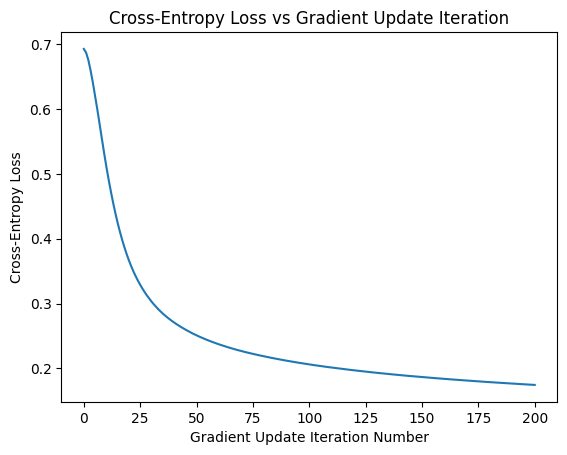

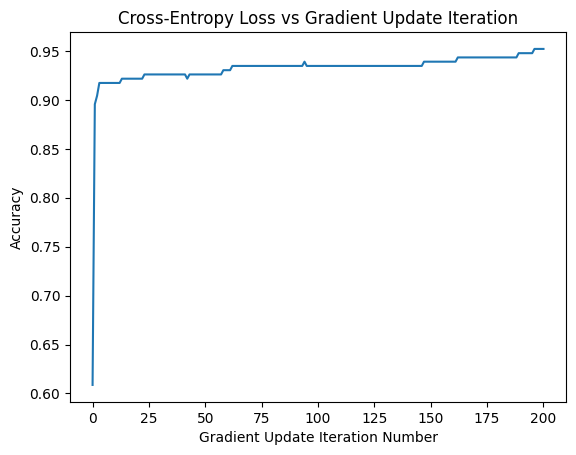

In [ ]:
MOMENTUM = 0.9

graddesc = GradientDescent(LEARNING_RATE, NUM_EPOCHS, BATCH_SIZE, EPSILON, MOMENTUM, True, REGULARIZATION_STRENGTH)
logistic_model = LogisticRegression(REGULARIZATION_STRENGTH)
logistic_model.fit(x_train, y_train, graddesc)
print("--TRAIN SET--")
y_pred = logistic_model.predict(x_train)
print(f"Cross-Entropy Loss: {logistic_model.cost(y_pred, y_train)}")
print(f"Accuracy: {logistic_model.accuracy(y_train, y_pred)}")
diff = [i for i in range(y_pred.shape[0]) if round(y_pred[i]) != np.array(y_train)[i]]
print(f"Our Model - {len(diff)}: {len(diff)/y_pred.shape[0] * 100}% misclassified")

print("--TEST SET--")
y_pred = logistic_model.predict(x_test)
print(f"Cross-Entropy Loss: {logistic_model.cost(y_pred, y_test)}")
print(f"Accuracy: {logistic_model.accuracy(y_test, y_pred)}")
diff = [i for i in range(y_pred.shape[0]) if round(y_pred[i]) != np.array(y_test)[i]]
print(f"Our Model - {len(diff)}: {len(diff)/y_pred.shape[0] * 100}% misclassified")

plt.plot(range(len(graddesc.cost_per_update)), graddesc.cost_per_update)
plt.title("Cross-Entropy Loss vs Gradient Update Iteration")
plt.xlabel("Gradient Update Iteration Number")
plt.ylabel("Cross-Entropy Loss")
plt.show()

plt.plot(range(len(graddesc.accuracy_per_update)), graddesc.accuracy_per_update)
plt.title("Cross-Entropy Loss vs Gradient Update Iteration")
plt.xlabel("Gradient Update Iteration Number")
plt.ylabel("Accuracy")
plt.show()

# Task 2: Hyperparameter Tuning with K-Fold Cross-Validation

**Hyperparameter Ranges**

In [ ]:
REGULARIZATION_STRENGTHS = [10e-2, 10e-3, 10e-4, 10e-5, 0]
BATCH_SIZES = [1, 16, 64]
EPOCHS = [50, 100, 150, 200]
LEARNING_RATES = [1, 10e-2, 10e-3, 10e-4, 10e-5]
NUM_FOLDS = 3

**Cross-Validation**

In [ ]:

def standardize_train_val(X_tr, X_val):
    #Standardize using TRAIN fold statistics only (prevents leakage).
    mu = X_tr.mean()
    sigma = X_tr.std().replace(0, 1)
    return (X_tr - mu) / sigma, (X_val - mu) / sigma

def make_k_folds(n, k=3, seed=2026):
    #Return a list of index arrays, one per fold.
    rng_local = np.random.default_rng(seed)
    idx = np.arange(n)
    rng_local.shuffle(idx)
    return np.array_split(idx, k)

def cv_score_config(X, y, k, lr, batch, iters, reg, epsilon=1e-4, seed=2026):

    #Runs K-fold CV for one hyperparameter configuration.
    #Returns mean/stdev of cross-entropy loss and accuracy across folds.

    folds = make_k_folds(len(X), k=k, seed=seed)

    fold_tr_losses = []
    fold_tr_accs = []
    fold_val_losses = []
    fold_val_accs = []

    for i in range(k):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])

        X_tr = X.iloc[train_idx].copy()
        y_tr = y.iloc[train_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_val = y.iloc[val_idx].copy()

        #standardize within fold (NO leakage)
        X_tr_std, X_val_std = standardize_train_val(X_tr, X_val)

        #train
        gd = GradientDescent(
            learning_rate=lr,
            max_iters=iters,
            batch_size=batch,
            epsilon=epsilon,
            momentum=0,
            track_cost_per_update=False,
            reg_strength=reg
        )
        model = LogisticRegression(reg)
        model.fit(X_tr_std, y_tr, gd)

        # validate
        y_val_prob = model.predict(X_val_std)
        loss = model.cost(y_val_prob, y_val)
        acc = model.accuracy(y_val, y_val_prob)

        fold_val_losses.append(loss)
        fold_val_accs.append(acc)

        # training loss & acc
        y_tr_prob = model.predict(X_tr_std)
        loss = model.cost(y_tr_prob, y_tr)
        acc = model.accuracy(y_tr, y_tr_prob)

        fold_tr_losses.append(loss)
        fold_tr_accs.append(acc)
    return {
        "val_mean_loss": float(np.mean(fold_val_losses)),
        "val_std_loss": float(np.std(fold_val_losses)),
        "val_mean_acc": float(np.mean(fold_val_accs)),
        "val_std_acc": float(np.std(fold_val_accs)),
        "tr_mean_loss": float(np.mean(fold_tr_losses)),
        "tr_std_loss": float(np.std(fold_tr_losses)),
        "tr_mean_acc": float(np.mean(fold_tr_accs)),
        "tr_std_acc": float(np.std(fold_tr_accs)),
    }

**Hyperparameter Selection**

In [ ]:
#run CV over the hyperparameter grid (on TRAIN set only)
cv_results = []

#use x_train/y_train here (not x_test)
X_cv = x_train
y_cv = y_train

for lr in LEARNING_RATES:
    for batch in BATCH_SIZES:
        for iters in EPOCHS:  # "iters" = max_iters in GD
            for reg in REGULARIZATION_STRENGTHS:
                stats = cv_score_config(
                    X_cv, y_cv,
                    k=NUM_FOLDS,
                    lr=lr,
                    batch=batch,
                    iters=iters,
                    reg=reg,
                    epsilon=EPSILON,
                    seed=2026
                )
                cv_results.append({
                    "lr": lr,
                    "batch": batch,
                    "iters": iters,
                    "reg": reg,
                    **stats
                })

results_df = pd.DataFrame(cv_results)

# Sort by best accuracy, tie-break by lowest loss
results_df = results_df.sort_values(by=["val_mean_acc", "val_mean_loss"], ascending=[False, True])

# Show top configs
results_df.head(15)

,lr,batch,iters,reg,val_mean_loss,val_std_loss,val_mean_acc,val_std_acc,tr_mean_loss,tr_std_loss,tr_mean_acc,tr_std_acc
259,0.0001,1,200,0.0000,0.679788,0.002234,0.921679,0.018655,0.680206,0.000498,0.919574,0.016256
193,0.0010,1,150,0.0001,0.608246,0.014028,0.917407,0.026635,0.609276,0.003503,0.919574,0.016256
194,0.0010,1,150,0.0000,0.608873,0.013617,0.917407,0.026635,0.609503,0.003424,0.921738,0.010676
206,0.0010,16,100,0.0100,0.633285,0.010104,0.917407,0.026635,0.634663,0.002390,0.917395,0.013403
249,0.0001,1,100,0.0000,0.686409,0.001217,0.917407,0.016113,0.686779,0.000260,0.910873,0.013401
260,0.0001,16,50,0.1000,0.689702,0.000620,0.917407,0.026635,0.689882,0.000133,0.919574,0.016256
258,0.0001,1,200,0.0001,0.679182,0.002609,0.917350,0.022237,0.680237,0.000628,0.917381,0.021603
254,0.0001,1,150,0.0000,0.682965,0.001894,0.917350,0.022237,0.683411,0.000420,0.917395,0.013403
248,0.0001,1,100,0.0001,0.686302,0.001514,0.913078,0.021945,0.686708,0.000319,0.919574,0.011040
143,0.0100,16,50,0.0001,0.501070,0.028196,0.913021,0.026756,0.491982,0.007157,0.919574,0.016256


In [ ]:
#cross validation results table

best = results_df.iloc[0]
print("Best config (by CV):")
print(best)

Best config (by CV):
lr                 0.000100
batch              1.000000
iters            200.000000
reg                0.000000
val_mean_loss      0.679788
val_std_loss       0.002234
val_mean_acc       0.921679
val_std_acc        0.018655
tr_mean_loss       0.680206
tr_std_loss        0.000498
tr_mean_acc        0.919574
tr_std_acc         0.016256
Name: 259, dtype: float64


**Model Training using Selected Hyperparameters**

In [ ]:
best_lr = float(best["lr"])
best_batch = int(best["batch"])
best_iters = int(best["iters"])
best_reg = float(best["reg"])

print("Chosen hyperparameters:")
print("lr =", best_lr, "| batch =", best_batch, "| iters =", best_iters, "| reg =", best_reg)

#standardize x_train/x_test using TRAIN stats
#here assume x_train and x_test are already standardized correctly

gd_best = GradientDescent(
    learning_rate=best_lr,
    max_iters=best_iters,
    batch_size=best_batch,
    epsilon=EPSILON,
    momentum=0,
    track_cost_per_update=False,
    reg_strength=best_reg
)

final_model = LogisticRegression(best_reg)
final_model.fit(x_train, y_train, gd_best)

y_test_prob = final_model.predict(x_test)
test_loss = final_model.cost(y_test_prob, y_test)
test_acc = final_model.accuracy(y_test, y_test_prob)

print("Final TEST Cross-Entropy:", test_loss)
print("Final TEST Accuracy:", test_acc)

Chosen hyperparameters:
lr = 0.0001 | batch = 1 | iters = 200 | reg = 0.0
Final TEST Cross-Entropy: 0.6808388102701658
Final TEST Accuracy: 0.883321894303363


# Task 3: Bias–Variance Trade-Off via λ Sweep (With K-Fold CV)

**λ Grid**

In [ ]:
REGULARIZATION_STRENGTHS = [0, 10e-7, 10e-6, 10e-5, 10e-4, 10e-3, 10e-2, 1]

LEARNING_RATE = 0.1
BATCH_SIZE = 16
EPOCHS = 200

**Sweep with CV**

In [ ]:
training_loss = []
validation_loss = []
training_accs = []
validation_accs = []

#use x_train/y_train
X_cv = x_train
y_cv = y_train

for reg in REGULARIZATION_STRENGTHS:
  stats = cv_score_config(
      X_cv, y_cv,
      k=NUM_FOLDS,
      lr=LEARNING_RATE,
      batch=BATCH_SIZE,
      iters=EPOCHS,
      reg=reg,
      epsilon=EPSILON,
      seed=2026
  )
  training_loss.append(stats["tr_mean_loss"])
  training_accs.append(stats["tr_mean_acc"])
  validation_loss.append(stats["val_mean_loss"])
  validation_accs.append(stats["val_mean_acc"])

**Sweep Plots**

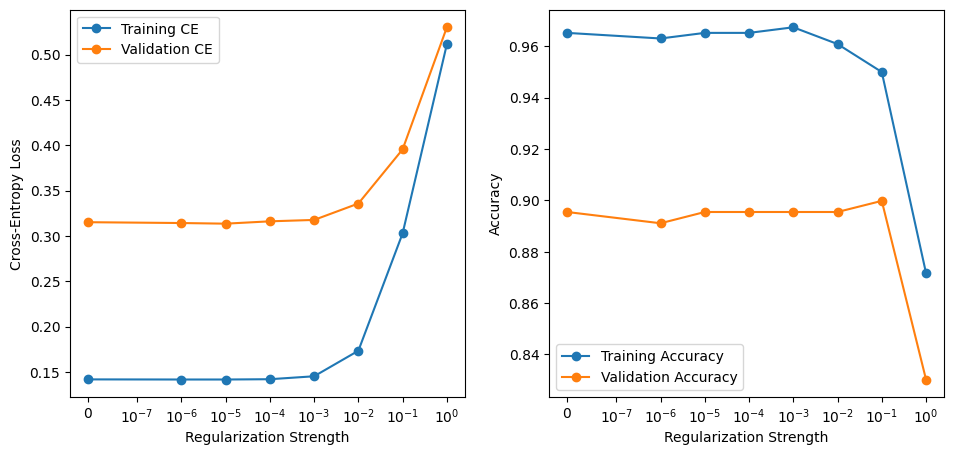

In [ ]:
figure, axes = plt.subplots(1, 2, figsize=(10, 5))
figure.tight_layout(pad=3)

axes[0].plot(REGULARIZATION_STRENGTHS, training_loss, label='Training CE', marker='o')
axes[0].plot(REGULARIZATION_STRENGTHS, validation_loss, label='Validation CE', marker='o')
axes[0].set_xscale("symlog", linthresh=10e-8)
axes[0].set_xlabel("Regularization Strength")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend(loc="upper left")

axes[1].plot(REGULARIZATION_STRENGTHS, training_accs, label='Training Accuracy', marker='o')
axes[1].plot(REGULARIZATION_STRENGTHS, validation_accs, label='Validation Accuracy', marker='o')
axes[1].set_xscale("symlog", linthresh=10e-8)
axes[1].set_xlabel("Regularization Strength")
axes[1].set_ylabel("Accuracy")
axes[1].legend(loc="lower left")

plt.show()

**λ Value Selection & Evaluation**

In [ ]:
#Sort by highest acc on validation, tie break with lowest loss on validation
merged = list(zip(validation_accs, validation_loss, REGULARIZATION_STRENGTHS))
merged.sort(key=lambda x: (x[0], -x[1]))
selected_reg_strength = merged[-1][2]
print(f"Selected Regularization Strength: {selected_reg_strength}")


graddesc = GradientDescent(learning_rate=LEARNING_RATE, max_iters=NUM_EPOCHS,
                           batch_size=BATCH_SIZE, epsilon=EPSILON, momentum=0,
                           track_cost_per_update=False, reg_strength=selected_reg_strength)

logistic_model = LogisticRegression(selected_reg_strength)
final_model.fit(x_train, y_train, graddesc)

y_pred = final_model.predict(x_test)
loss = final_model.cost(y_pred, y_test)
acc = final_model.accuracy(y_test, y_pred)

print("Test Cross-Entropy:", loss)
print("Test Accuracy:", acc)

Selected Regularization Strength: 0.1
Test Cross-Entropy: 0.3212886612204258
Test Accuracy: 0.8878975062914665


**BONUS: Dataset Size Sweep**

In [ ]:
TRAIN_RATIOS = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
REGULARIZATION_STRENGTH = 0.1 # Fixed

In [ ]:
training_loss = []
validation_loss = []
training_accs = []
validation_accs = []


for ratio in TRAIN_RATIOS:
  X_cv, _, y_cv, _ = split_train_test(ratio)
  stats = cv_score_config(
      X_cv, y_cv,
      k=NUM_FOLDS,
      lr=LEARNING_RATE,
      batch=BATCH_SIZE,
      iters=EPOCHS,
      reg=REGULARIZATION_STRENGTH,
      epsilon=EPSILON,
      seed=2026
  )
  training_loss.append(stats["tr_mean_loss"])
  training_accs.append(stats["tr_mean_acc"])
  validation_loss.append(stats["val_mean_loss"])
  validation_accs.append(stats["val_mean_acc"])

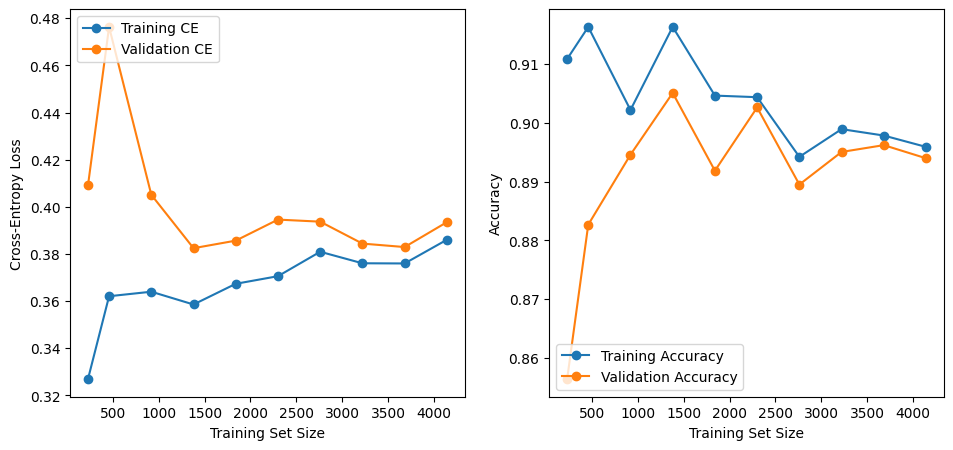

In [ ]:
train_sizes = [int(ratio * x.shape[0]) for ratio in TRAIN_RATIOS]
figure, axes = plt.subplots(1, 2, figsize=(10, 5))
figure.tight_layout(pad=3)

axes[0].plot(train_sizes, training_loss, label='Training CE', marker='o')
axes[0].plot(train_sizes, validation_loss, label='Validation CE', marker='o')
axes[0].set_xlabel("Training Set Size")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend(loc="upper left")

axes[1].plot(train_sizes, training_accs, label='Training Accuracy', marker='o')
axes[1].plot(train_sizes, validation_accs, label='Validation Accuracy', marker='o')
axes[1].set_xlabel("Training Set Size")
axes[1].set_ylabel("Accuracy")
axes[1].legend(loc="lower left")

plt.show()

# Task 4: L1-Regularized Logistic Regression and the Regularization Path

**Regularization path of coefficients**

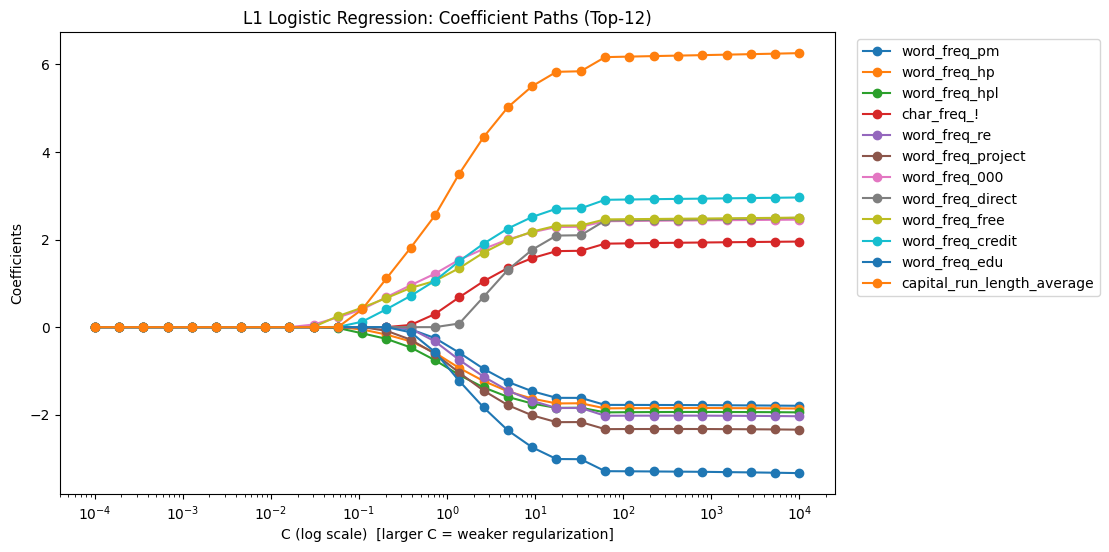

In [ ]:
from sklearn.linear_model import LogisticRegression

Cs = np.logspace(-4, 4, 30)

coefs = []        # list of coefficients vectors
nnz = []          # number of non-zero weights
test_acc = []     # optional: test accuracy for each C

clf = LogisticRegression(
    penalty = "l1",
    solver="saga",
    max_iter=5000,
    warm_start=True,
    random_state=2026
)

for C in Cs:
  clf.set_params(C=C)
  clf.fit(x_train, y_train)

  w = clf.coef_.ravel()
  coefs.append(w)

# number of non-zeros : count of weights whos abs value is > small tolerance
  nnz.append(np.sum(np.abs(w) > 1e-8))

coefs = np.array(coefs)
nnz = np.array(nnz)

# Helps choose the strongest coefficients either - or +
k = 12
max_abs = np.max(np.abs(coefs), axis=0)
topk_idx = np.argsort(max_abs)[-k:]

plt.figure(figsize=(10,6))
for j in topk_idx:
  plt.plot(Cs, coefs[:,j], marker="o", label=feature_names[j])
plt.xscale("log")
plt.xlabel("C (log scale)  [larger C = weaker regularization]")
plt.ylabel("Coefficients")
plt.title(f"L1 Logistic Regression: Coefficient Paths (Top-{k})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.axis("tight")
plt.show()

**Sparsity plot**

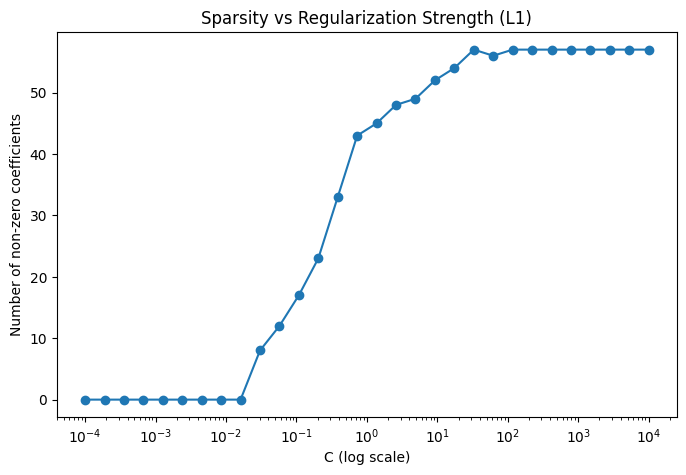

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(Cs, nnz, marker="o")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Number of non-zero coefficients")
plt.title("Sparsity vs Regularization Strength (L1)")
plt.axis("tight")
plt.show()

**CV performance vs C**

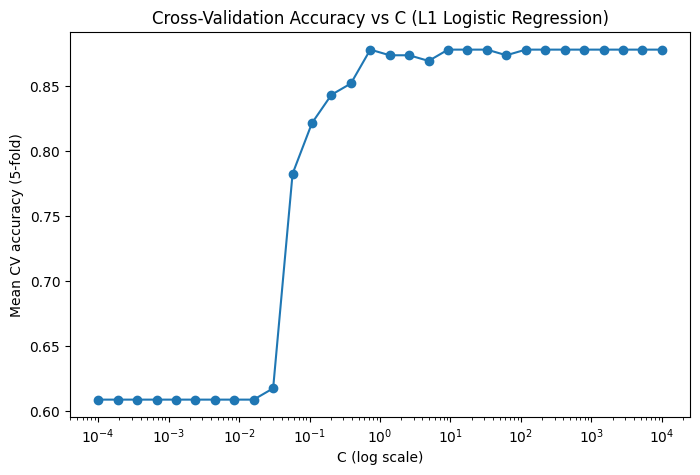

Best C selected by CV: 0.7278953843983146


In [ ]:
from sklearn.linear_model import LogisticRegressionCV

cv_model = LogisticRegressionCV(
    Cs=Cs,
    cv=5,
    penalty="l1",
    solver="saga",
    scoring="accuracy",
    max_iter=5000,
    n_jobs=-1,
    random_state=2026,
    refit=True
)
cv_model.fit(x_train, y_train)

mean_cv_acc = cv_model.scores_[1].mean(axis=0)

plt.figure(figsize=(8, 5))
plt.plot(Cs, mean_cv_acc, marker="o")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Mean CV accuracy (5-fold)")
plt.title("Cross-Validation Accuracy vs C (L1 Logistic Regression)")
plt.axis("tight")
plt.show()

best_C = cv_model.C_[0]
print("Best C selected by CV:", best_C)